In [1]:
# This cell is removed with the tag: "remove-input"
# As such, it will not be shown in documentation

import warnings
warnings.filterwarnings('ignore')


(Tutorial_Get_principal_axes)=
# Get principal axes

*Calculating principal axes of inertia and principal moments of a molecular system.*

The function {func}`molsysmt.structure.get_principal_axes` diagonalizes the inertia tensor (or geometric second-moment tensor) to compute the principal axes and corresponding moments across single or multiple structures.

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

Follow this link for a detailed description of the input arguments, raised errors, and returned objects of this function: {func}`molsysmt.structure.get_principal_axes`.
:::


## Basic usage

Let's show how to compute the geometric principal axes of an 8-corner rectangular box:


In [2]:
import molsysmt as msm
import numpy as np
import matplotlib.pyplot as plt
import pyunitwizard as puw


In [3]:
coords = np.array([[
    [0.0, 0.0, 0.0],
    [2.0, 0.0, 0.0],
    [0.0, 1.0, 0.0],
    [2.0, 1.0, 0.0],
    [0.0, 0.0, 0.5],
    [2.0, 0.0, 0.5],
    [0.0, 1.0, 0.5],
    [2.0, 1.0, 0.5]
]]) * msm.pyunitwizard.unit('nm')


We compute the principal axes and moments using {func}`molsysmt.structure.get_principal_axes`:


In [4]:
axes, moments = msm.structure.get_principal_axes(coords)


In [5]:
print('Principal axes eigenvectors shape:', axes.shape)
print('Principal moments shape:', moments.shape)
for i in range(3):
    print(f'Axis {i+1}: vector = {axes[0, i]}, moment = {moments[0, i]:.3f}')


Principal axes eigenvectors shape: (1, 3, 3)
Principal moments shape: (1, 3)
Axis 1: vector = [1. 0. 0.], moment = 2.500
Axis 2: vector = [0. 1. 0.], moment = 8.500
Axis 3: vector = [0. 0. 1.], moment = 10.000


## Mass-weighted principal moments of inertia

Passing `weights='masses'` computes the physical moments of inertia on a macromolecular structure:


In [6]:
molsys = msm.convert(msm.systems['chicken villin HP35']['chicken_villin_HP35.h5msm'])
axes_prot, moments_prot = msm.structure.get_principal_axes(molsys, selection='atom_type!="H"', weights='masses')
print('Protein principal moments of inertia:', moments_prot[0])


Protein principal moments of inertia: [1562.36043789 2269.1324253  2915.29026336]


:::{note} Demo Systems Catalog
:class: dropdown

This tutorial uses demonstration datasets provided by MolSysMT. To explore the full catalog of bundled systems, forms, and file paths, visit the {ref}`Demo Systems <user-foundations-entrance-demo-systems>` guide.
:::


## Principal moments evolution across structural ensembles

We calculate the principal moments of inertia along a trajectory to analyze conformational shape changes:


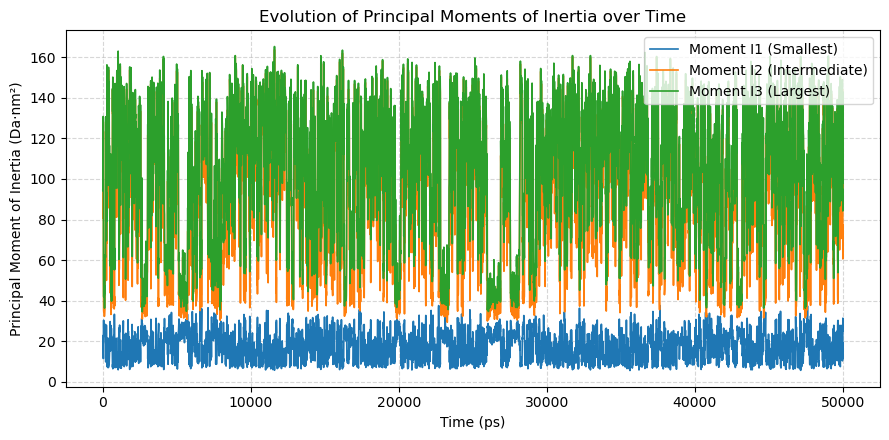

In [7]:
traj = msm.convert(msm.systems['pentalanine']['traj_pentalanine.h5msm'])
axes_traj, moments_traj = msm.structure.get_principal_axes(traj, selection='atom_type!="H"', weights='masses')
time = msm.get(traj, element='system', time=True)
time_val = puw.get_value(time, to_unit='ps')

plt.figure(figsize=(9, 4.5))
plt.plot(time_val, moments_traj[:, 0], label='Moment I1 (Smallest)', lw=1.2)
plt.plot(time_val, moments_traj[:, 1], label='Moment I2 (Intermediate)', lw=1.2)
plt.plot(time_val, moments_traj[:, 2], label='Moment I3 (Largest)', lw=1.2)
plt.xlabel('Time (ps)')
plt.ylabel('Principal Moment of Inertia (Da·nm²)')
plt.title('Evolution of Principal Moments of Inertia over Time')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


:::{seealso} Related Tools & References
:class: dropdown

- {ref}`Convert <Tutorial_Convert>`: Convert molecular systems between different forms with {func}`molsysmt.basic.convert`.
- {ref}`Get center <Tutorial_Get_center>`: Compute the geometric center or center of mass with {func}`molsysmt.structure.get_center`.
- {ref}`Align principal axes <Tutorial_Align_principal_axes>`: Align molecular principal axes with Cartesian frame axes with {func}`molsysmt.structure.align_principal_axes`.
- {ref}`Get radius of gyration <Tutorial_Get_radius_of_gyration>`: Measure spatial extent with {func}`molsysmt.structure.get_radius_of_gyration`.
:::
